/var/folders/2t/401nrwwj35q9x5t3qyj2wtp00000gn/T/ipykernel_22399/3112285771.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


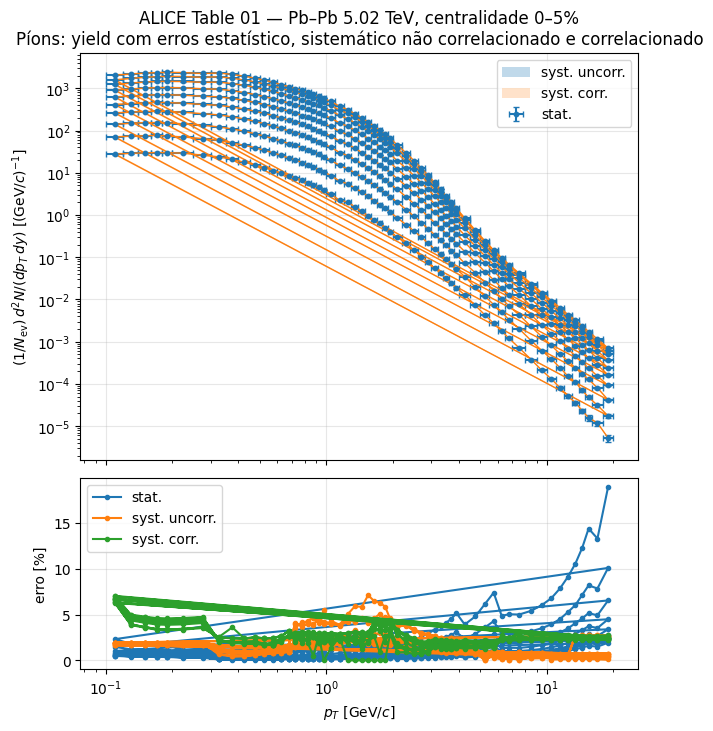

Arquivo salvo em: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/experimental-correlation-uncertainty/plot_table01_pions_0_5.png
Descrição: $p_{T}$-distributions of pions ($\pi^{+}+\pi^{-}$) measured in Pb-Pb collisions at $\sqrt{s_{NN}}$ = 5.02 TeV.
DOI: 10.17182/hepdata.104923.v1/t1


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("10.17182/HEPData-ins1759506-v1-csv/")
TABLE_FILE = DATA_DIR / "Table01.csv"  # centralidade 0.0-5.0 para píons em Pb-Pb


def read_hepdata_csv(path: Path) -> tuple[dict, pd.DataFrame]:
    metadata = {}
    lines = path.read_text(encoding="utf-8").splitlines()

    data_start = None
    for i, line in enumerate(lines):
        if line.startswith("#:"):
            body = line[2:].strip()
            if ":" in body:
                key, value = body.split(":", 1)
                metadata[key.strip()] = value.strip()
        elif line.startswith("#"):
            continue
        elif line.strip():
            data_start = i
            break

    if data_start is None:
        raise ValueError(f"Nenhuma tabela encontrada em {path}")

    from io import StringIO
    df = pd.read_csv(StringIO("\n".join(lines[data_start:])))
    df.columns = [c.strip() for c in df.columns]
    return metadata, df



def main() -> None:
    metadata, df = read_hepdata_csv(TABLE_FILE)

    # --- FILTRO CENTRALIDADE 0–5% ---
    x_tmp = pd.to_numeric(df[r"$p_{T}$ [$GeV/c$]"], errors="coerce")

    split_idx = []
    for i in range(1, len(x_tmp)):
        if x_tmp.iloc[i] < x_tmp.iloc[i-1]:
            split_idx.append(i)

    end = split_idx[0] if len(split_idx) > 0 else len(x_tmp)
    df = df.iloc[:end].copy()
    # --------------------------------

    x = pd.to_numeric(df[r"$p_{T}$ [$GeV/c$]"], errors="coerce")
    xlow = pd.to_numeric(df[r"$p_{T}$ [$GeV/c$] LOW"], errors="coerce")
    xhigh = pd.to_numeric(df[r"$p_{T}$ [$GeV/c$] HIGH"], errors="coerce")
    y = pd.to_numeric(df[r"(1/Nev)*D2(N)/DPT/DYRAP [$(GeV/c)^{-1}$]"], errors="coerce")

    stat = pd.to_numeric(df["stat. +"], errors="coerce").abs()
    syst = pd.to_numeric(df["syst. +"], errors="coerce").abs()
    syst_uncorr = pd.to_numeric(df["syst. uncorr. +"], errors="coerce").abs()

    syst_corr = np.sqrt(np.clip(syst**2 - syst_uncorr**2, a_min=0.0, a_max=None))

    mask = x.notna() & xlow.notna() & xhigh.notna() & y.notna()
    x = x[mask].to_numpy()
    xlow = xlow[mask].to_numpy()
    xhigh = xhigh[mask].to_numpy()
    y = y[mask].to_numpy()
    stat = stat[mask].to_numpy()
    syst = syst[mask].to_numpy()
    syst_uncorr = syst_uncorr[mask].to_numpy()
    syst_corr = syst_corr[mask].to_numpy()

    xerr = np.vstack([x - xlow, xhigh - x])

    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(7.2, 8.0), sharex=True,
        gridspec_kw={"height_ratios": [3.2, 1.5], "hspace": 0.06}
    )

    ax.fill_between(
        x, y - syst_uncorr, y + syst_uncorr,
        alpha=0.28, label="syst. uncorr."
    )
    ax.fill_between(
        x, y - syst_corr, y + syst_corr,
        alpha=0.22, label="syst. corr."
    )
    ax.errorbar(
        x, y, xerr=xerr, yerr=stat,
        fmt="o", ms=3.2, capsize=2, label="stat."
    )
    ax.plot(x, y, linewidth=1)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel(r"$(1/N_{\rm ev})\, d^2N/(dp_T\,dy)$ [$(\mathrm{GeV}/c)^{-1}$]")
    ax.set_title(
        "ALICE Table 01 — Pb–Pb 5.02 TeV, centralidade 0–5%\n"
        "Píons: yield com erros estatístico, sistemático não correlacionado e correlacionado"
    )
    ax.grid(True, alpha=0.3)
    ax.legend()

    rel_stat = 100.0 * stat / y
    rel_unc = 100.0 * syst_uncorr / y
    rel_corr = 100.0 * syst_corr / y

    axr.plot(x, rel_stat, "o-", ms=3, label="stat.")
    axr.plot(x, rel_unc, "o-", ms=3, label="syst. uncorr.")
    axr.plot(x, rel_corr, "o-", ms=3, label="syst. corr.")
    axr.set_xscale("log")
    axr.set_xlabel(r"$p_T$ [GeV/$c$]")
    axr.set_ylabel("erro [%]")
    axr.grid(True, alpha=0.3)
    axr.legend()

    out = Path("plot_table01_pions_0_5.png")
    fig.tight_layout()
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()

    print("Arquivo salvo em:", out.resolve())
    print("Descrição:", metadata.get("description", ""))
    print("DOI:", metadata.get("table_doi", ""))


if __name__ == "__main__":
    main()

In [1]:
main()


NameError: name 'main' is not defined

In [4]:
import ROOT
import pandas as pd
import numpy as np

# caminho
file = "10.17182/HEPData-ins1759506-v1-csv/Table01.csv"

# --- leitura robusta HEPData ---
def read_hepdata_csv(path):
    lines = open(path).read().splitlines()
    data_start = None

    for i, line in enumerate(lines):
        if not line.startswith("#") and line.strip():
            data_start = i
            break

    from io import StringIO
    df = pd.read_csv(StringIO("\n".join(lines[data_start:])))
    df.columns = [c.strip() for c in df.columns]
    return df

df = read_hepdata_csv(file)

# --- converter ---
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

x = to_num(df[r"$p_{T}$ [$GeV/c$]"])
xlow = to_num(df[r"$p_{T}$ [$GeV/c$] LOW"])
xhigh = to_num(df[r"$p_{T}$ [$GeV/c$] HIGH"])
y = to_num(df[r"(1/Nev)*D2(N)/DPT/DYRAP [$(GeV/c)^{-1}$]"])

stat = to_num(df["stat. +"]).abs()
syst = to_num(df["syst. +"]).abs()
syst_unc = to_num(df["syst. uncorr. +"]).abs()

# --- correlacionado ---
syst_corr = np.sqrt(np.clip(syst**2 - syst_unc**2, 0, None))

# --- pegar apenas centralidade 0–5 ---
split = None
for i in range(1, len(x)):
    if x.iloc[i] < x.iloc[i-1]:
        split = i
        break

if split is None:
    split = len(x)

x = x.iloc[:split]
xlow = xlow.iloc[:split]
xhigh = xhigh.iloc[:split]
y = y.iloc[:split]
stat = stat.iloc[:split]
syst_unc = syst_unc.iloc[:split]
syst_corr = syst_corr.iloc[:split]

# remover NaNs
mask = x.notna() & y.notna()
x = x[mask].to_numpy()
xlow = xlow[mask].to_numpy()
xhigh = xhigh[mask].to_numpy()
y = y[mask].to_numpy()
stat = stat[mask].to_numpy()
syst_unc = syst_unc[mask].to_numpy()
syst_corr = syst_corr[mask].to_numpy()

# --- ROOT objects ---
n = len(x)

g_stat = ROOT.TGraphAsymmErrors(n)
g_unc = ROOT.TGraph(n)
g_corr = ROOT.TGraph(n)

for i in range(n):
    exl = x[i] - xlow[i]
    exh = xhigh[i] - x[i]

    # stat
    g_stat.SetPoint(i, x[i], y[i])
    g_stat.SetPointError(i, exl, exh, stat[i], stat[i])

    # uncorr
    g_unc.SetPoint(i, x[i], y[i])

    # corr
    g_corr.SetPoint(i, x[i], y[i])

# --- canvas ---
c = ROOT.TCanvas("c", "", 800, 600)
c.SetLogx()
c.SetLogy()

# estilo
g_stat.SetMarkerStyle(20)
g_stat.SetMarkerSize(0.8)

g_unc.SetFillColorAlpha(ROOT.kOrange, 0.3)
g_corr.SetFillColorAlpha(ROOT.kRed, 0.25)

# desenhar
g_unc.Draw("A3")     # banda uncorr
g_corr.Draw("3 SAME")  # banda corr
g_stat.Draw("P SAME")  # pontos

g_unc.GetXaxis().SetTitle("p_{T} [GeV/c]")
g_unc.GetYaxis().SetTitle("(1/N) d^{2}N / dp_{T} dy")

# legenda
leg = ROOT.TLegend(0.65,0.7,0.88,0.88)
leg.AddEntry(g_stat, "stat.", "p")
leg.AddEntry(g_unc, "syst. uncorr.", "f")
leg.AddEntry(g_corr, "syst. corr.", "f")
leg.Draw()

c.Draw()
c.SaveAs("root_table01_0_5.pdf")

ModuleNotFoundError: No module named 'ROOT'